# Notebook 05 — Critical Zones (Objective 2: Grid Viability Analysis)

* **Mandate:** *"identify areas within the network that currently limit the deployment of charging infrastructure due to electrical grid congestion"* — IE-Iberdrola Datathon March 2026, Objective 2.
* **Relationship to Obj 1:** This notebook takes the unified grid-node database (`grid_nodes.csv`, 5,927 substations) built for Objective 1 and scores **every** node for reinforcement priority, producing a network-wide friction map that extends — but does not replace — the 14-row `File_3.csv` mandated by the datathon.
* **Method:** Node ⟷ corridor spatial join → capacity band classification (same empirical thresholds as Obj 1) → deficit × demand priority score → ranked `critical_zones.csv` + geospatial map.
* **Submission impact:** `File_3.csv` is **unchanged** (14 rows, 7 mandatory columns). `critical_zones.csv` is a **supplementary** layer feeding the Deliverable 3 BI Visualization ("additional layers… positively valued") and the Analytical Report's reinforcement-roadmap section.

## 1 · Imports & parameters

* **Reuses Obj 1 constants** — same grid-status bands, same feasibility gate, same voltage table.
* **New:** `NODE_ROAD_BUFFER_KM = 25` (a node further than 25 km from an interurban corridor cannot serve interurban charging in the 2027 horizon).
* **New:** `TARGET_MW = 1.2` — minimum capacity to comfortably host an 8-charger 150 kW pool (8 × 150 kW = 1.2 MW). Used as the deficit reference.
* **Priority score:** `deficit_MW × peak_daily_sessions_2027` where `deficit_MW = max(0, TARGET_MW − capacidad_firme_MW)`.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ---- Obj 1 constants (kept identical) ----
MW_SUFFICIENT      = 5.0    # > 5 MW  -> Sufficient  (green)
MW_MODERATE_MIN    = 1.0    # 1-5 MW  -> Moderate    (yellow)
                            # < 1 MW  -> Congested   (red)
MIN_CAP_MW_BUILD   = 0.001  # strict zero-MW feasibility gate (Obj 1)

# ---- i-DE voltage-to-max-chargers table (Mapa de Capacidad de Consumo 2025) ----
VOLT_MAX_CH = [(15, 2), (20, 4), (45, 8), (999, 8)]   # (upper kV, max chargers)

# ---- Obj 2 new constants ----
NODE_ROAD_BUFFER_KM = 25.0  # interurban-relevance buffer
TARGET_MW           = 1.2   # 8 chargers × 150 kW pool
KW_PER_CHARGER      = 150   # Rule 2 of datathon
DEG_PER_KM          = 1.0 / 111.0

# ---- paths ----
ROOT    = Path("/sessions/relaxed-friendly-einstein/mnt/Iberdrola_Datathon")
PROC    = ROOT / "data" / "processed"
OUT     = ROOT / "outputs"
FIGDIR  = ROOT / "03_grid_viability" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)
print("Paths OK.  Constants loaded.")


Paths OK.  Constants loaded.


## 2 · Load inputs

* **`grid_nodes.csv`** — 5,927 substations with lat/lon, voltage, capacidad firme, distributor label (built in `02_charging_network/build_grid_nodes.py`).
* **`roads_interurban_dissolved.geojson`** — autopistas + autovías + carreteras nacionales (Ministry of Transport, filtered to interurban per scope rule p.2 of brief).
* **`demand_by_corridor.csv`** — 19 corridors with `peak_daily_sessions` projected for 2027 from DGT + datos.gob.es fork.
* **`File_2.csv` and `File_3.csv`** — for overlay and sanity check that critical_zones is additive, not contradictory.

In [2]:
# Grid nodes
grid = pd.read_csv(PROC / "grid_nodes.csv")
print(f"grid_nodes.csv           : {len(grid):>5} rows")

# Roads (interurban-only)
roads = gpd.read_file(PROC / "roads_interurban_dissolved.geojson")
if roads.crs is None:
    roads.set_crs(epsg=4326, inplace=True)
print(f"roads_interurban         : {len(roads):>5} features")

# Corridor demand — index column is the corridor name (A-2, AP-7, etc.)
corr = pd.read_csv(PROC / "demand_by_corridor.csv", index_col=0)
corr.index.name = "corridor"
print(f"demand_by_corridor.csv   : {len(corr):>5} corridors")

# Obj 1 deliverables
file2 = pd.read_csv(OUT / "File_2.csv")
file3 = pd.read_csv(OUT / "File_3.csv")
print(f"File_2.csv (proposed)    : {len(file2):>5} rows")
print(f"File_3.csv (friction pts): {len(file3):>5} rows  (must stay at this number)")


grid_nodes.csv           :  5927 rows


roads_interurban         :   191 features
demand_by_corridor.csv   :    19 corridors
File_2.csv (proposed)    :    18 rows
File_3.csv (friction pts):    14 rows  (must stay at this number)


## 3 · Apply the feasibility gate and classify every node

* **Feasibility gate** (Obj 1 rule): drop nodes where `capacidad_firme_MW < MIN_CAP_MW_BUILD` (effectively exactly-zero) — these are not reinforcement candidates, they are physical no-builds until brand-new substation construction.
* **Grid-status bands** (datathon image + Obj 1): `<1 MW = Congested`, `1-5 MW = Moderate`, `>5 MW = Sufficient`.
* **Max chargers by voltage** (i-DE Mapa de Capacidad 2025): `<15 kV→2`, `15-19 kV→4`, `20-44 kV→8`, `≥45 kV→8`.
* Output: same classification every proposed station in File_2 already uses, so `critical_zones` aligns perfectly with `File_2`/`File_3` semantics.

In [3]:
def classify_grid_status(cap_mw: float) -> str:
    if pd.isna(cap_mw): return "Unknown"
    if cap_mw > MW_SUFFICIENT:      return "Sufficient"
    if cap_mw >= MW_MODERATE_MIN:   return "Moderate"
    return "Congested"

def max_chargers_by_voltage(kv: float) -> int:
    if pd.isna(kv): return 2
    for upper, nmax in VOLT_MAX_CH:
        if kv < upper: return nmax
    return 8

# Apply feasibility gate (strict zero-MW — Obj 1 rule)
n_before = len(grid)
grid = grid[grid["capacidad_firme_MW"] >= MIN_CAP_MW_BUILD].reset_index(drop=True)
print(f"Feasibility gate (>= {MIN_CAP_MW_BUILD} MW):  {n_before} -> {len(grid)} nodes")

grid["grid_status"]      = grid["capacidad_firme_MW"].apply(classify_grid_status)
grid["max_ch_by_voltage"] = grid["voltage_kv"].apply(max_chargers_by_voltage)

print("\nGrid-status distribution (all nodes post-gate):")
print(grid["grid_status"].value_counts().to_string())


Feasibility gate (>= 0.001 MW):  5927 -> 626 nodes

Grid-status distribution (all nodes post-gate):
grid_status
Moderate      252
Sufficient    249
Congested     125


## 4 · Distributor remap (Rule 1 compliance)

* Datathon Rule 1 accepts only `{i-DE, Endesa, Viesgo}` as `distributor_network` values.
* The raw data has 6 DSOs (i-DE, Endesa, Naturgy, Eredes, Viesgo, Begasa). The non-accepted ones are remapped by geography:
    * **Naturgy** (Madrid/Castilla-La Mancha/Galicia) → **i-DE**  *(same service regions)*
    * **Begasa** (Lugo/Galicia) → **i-DE**
    * **Eredes** (Asturias) → **Viesgo**  *(adjacent northern service area)*
* This preserves full capacity information while producing Rule-1-compliant output labels.

In [4]:
REMAP = {
    "i-DE":    "i-DE",
    "Naturgy": "i-DE",
    "Begasa":  "i-DE",
    "Endesa":  "Endesa",
    "Viesgo":  "Viesgo",
    "Eredes":  "Viesgo",
}
grid["distributor_network"] = grid["distributor"].map(REMAP).fillna("i-DE")

print("Remap summary:")
print(pd.crosstab(grid["distributor"], grid["distributor_network"]).to_string())


Remap summary:
distributor_network  Endesa  Viesgo  i-DE
distributor                              
Begasa                    0       0    20
Endesa                   71       0     0
Eredes                    0      96     0
Naturgy                   0       0   127
Viesgo                    0      88     0
i-DE                      0       0   224


## 5 · Node ⟷ interurban-corridor spatial join

* For each of the 5,920+ substations, compute **(a)** the nearest interurban corridor (A-/AP-/N-) and **(b)** the distance (km) to that corridor.
* We approximate corridor lines by sampling each dissolved geometry at ~2 km intervals, then running a `cKDTree` nearest-point lookup in degrees (converted to km via 111 km/deg).
* Nodes further than `NODE_ROAD_BUFFER_KM` (25 km) are dropped — they cannot host interurban charging stations and are outside Obj 2's scope (scope rule p.2 of brief).

In [5]:
# 5a) Flatten roads -> array of (lon, lat) samples with corridor label
SAMPLE_STEP_KM = 2.0
samples_lonlat = []
samples_name   = []

# roads geojson has a 'matricula' or 'name' style column — check schema
road_name_col = None
for c in ["matricula", "route_segment", "denominacion", "name", "codigo"]:
    if c in roads.columns:
        road_name_col = c
        break
if road_name_col is None:
    road_name_col = roads.columns[0]
print(f"Using road-name column: {road_name_col!r}")

for _, row in roads.iterrows():
    geom = row.geometry
    name = str(row[road_name_col])
    lines = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
    for ln in lines:
        length_km = ln.length / DEG_PER_KM
        n_samples = max(2, int(length_km / SAMPLE_STEP_KM))
        for t in np.linspace(0, 1, n_samples):
            pt = ln.interpolate(t, normalized=True)
            samples_lonlat.append((pt.x, pt.y))
            samples_name.append(name)

samples = np.array(samples_lonlat)
samples_name = np.array(samples_name)
print(f"Road samples: {len(samples):,}  from {len(roads)} corridor features")

# 5b) kd-tree lookup: nearest sample for every grid node
tree = cKDTree(samples)
node_xy = grid[["lon", "lat"]].values
d_deg, idx = tree.query(node_xy, k=1)
d_km = d_deg / DEG_PER_KM

grid["dist_to_corridor_km"] = d_km
grid["nearest_corridor_raw"] = samples_name[idx]

# 5c) Normalize corridor label so it matches demand_by_corridor.csv index
def norm_corridor(s: str) -> str:
    s = str(s).upper().strip()
    # common variants in MITMA dataset
    if s.startswith("N ")   : s = "N-"   + s[2:]
    if s.startswith("A ")   : s = "A-"   + s[2:]
    if s.startswith("AP ")  : s = "AP-"  + s[3:]
    return s.replace(" ", "")

grid["nearest_corridor"] = grid["nearest_corridor_raw"].apply(norm_corridor)

print(f"\nDistance to nearest interurban road (km):")
print(f"  median = {np.median(d_km):.2f}   p90 = {np.percentile(d_km,90):.2f}   max = {np.max(d_km):.2f}")
print(f"\nNodes within {NODE_ROAD_BUFFER_KM} km of an interurban corridor: "
      f"{(d_km <= NODE_ROAD_BUFFER_KM).sum()} / {len(grid)}")


Using road-name column: 'road'


Road samples: 487,465  from 191 corridor features

Distance to nearest interurban road (km):
  median = 2.83   p90 = 32.75   max = 924.82

Nodes within 25.0 km of an interurban corridor: 549 / 626


## 6 · Attach corridor demand to every node

* Merge each node's `nearest_corridor` with `demand_by_corridor.csv` to pick up `peak_daily_sessions` (projected 2027).
* Nodes whose nearest corridor doesn't appear in the demand table get `peak_daily_sessions = 0` — these are typically small secondary roads and will score zero priority regardless.
* This gives every node a **demand weight** that reflects how heavily trafficked its corridor is.

In [6]:
# Build a lookup dict from the corridor index
demand_lookup = corr["peak_daily_sessions"].to_dict()

# Some corridor names may differ slightly (e.g. 'N-II' vs 'N-2') — harmonize roman numerals:
ROMAN_MAP = {"N-I":"N-1","N-II":"N-2","N-III":"N-3","N-IV":"N-4","N-V":"N-5","N-VI":"N-6"}
demand_lookup_plus = dict(demand_lookup)
for k, v in list(demand_lookup.items()):
    if k in ROMAN_MAP:
        demand_lookup_plus[ROMAN_MAP[k]] = v
    # also store the roman form of arabic numbered ones
for arabic, roman in {v:k for k,v in ROMAN_MAP.items()}.items():
    if arabic in demand_lookup:
        demand_lookup_plus[roman] = demand_lookup[arabic]

grid["peak_daily_sessions_2027"] = grid["nearest_corridor"].map(demand_lookup_plus).fillna(0.0)

print("Corridor demand coverage:")
covered = (grid["peak_daily_sessions_2027"] > 0).sum()
print(f"  Nodes with a matched corridor demand: {covered} / {len(grid)}  ({100*covered/len(grid):.1f}%)")
print(f"  Top 5 corridors by aggregate node exposure:")
print(grid.groupby("nearest_corridor")["peak_daily_sessions_2027"]
      .agg(['count','max']).sort_values('max', ascending=False).head().to_string())


Corridor demand coverage:
  Nodes with a matched corridor demand: 188 / 626  (30.0%)
  Top 5 corridors by aggregate node exposure:
                  count        max
nearest_corridor                  
A-2                   8  43445.592
A-4                  11  31149.216
A-3                  17  26992.308
A-1                  22  25999.428
A-6                  17  22733.280


## 7 · Compute deficit, priority score and filter critical zones

* **Deficit (MW):** `max(0, TARGET_MW − capacidad_firme_MW)`. A Sufficient node has deficit = 0.
* **Priority score:** `deficit_MW × peak_daily_sessions_2027`. Highest priorities = high-demand corridors with tight capacity.
* **Filter to critical zones:** keep only nodes that are
    1. within 25 km of an interurban corridor, **and**
    2. classified `Moderate` or `Congested` (Sufficient = no reinforcement needed by definition), **and**
    3. have `priority_score > 0` (i.e., are actually exposed to corridor demand).
* **Reinforcement type** (inferred): `Congested → "New substation or major upgrade"`, `Moderate → "Transformer/feeder upgrade"`.

In [7]:
grid["deficit_MW"] = (TARGET_MW - grid["capacidad_firme_MW"]).clip(lower=0.0)
grid["priority_score"] = grid["deficit_MW"] * grid["peak_daily_sessions_2027"]

critical = grid[
    (grid["dist_to_corridor_km"] <= NODE_ROAD_BUFFER_KM) &
    (grid["grid_status"].isin(["Moderate", "Congested"])) &
    (grid["priority_score"] > 0)
].copy()

def reinforcement_type(row):
    return ("New substation or major upgrade"
            if row["grid_status"] == "Congested"
            else "Transformer / feeder upgrade")

critical["reinforcement_type"] = critical.apply(reinforcement_type, axis=1)

critical = critical.sort_values("priority_score", ascending=False).reset_index(drop=True)
critical["zone_id"] = [f"CRITZ_{i+1:03d}" for i in range(len(critical))]
print(f"Critical zones identified: {len(critical):,}")
print(f"  Congested: {(critical['grid_status']=='Congested').sum()}")
print(f"  Moderate : {(critical['grid_status']=='Moderate').sum()}")


Critical zones identified: 41
  Congested: 32
  Moderate : 9


## 8 · Assemble `critical_zones.csv` (supplementary output)

* **Not File_3 — this is a new, documented supplementary layer** with extra evidence columns for the report and the BI dashboard.
* **Column contract (17 cols):** `zone_id, latitude, longitude, subestacion, municipio, provincia, distributor_network, voltage_kv, capacidad_firme_MW, grid_status, nearest_corridor, dist_to_corridor_km, peak_daily_sessions_2027, deficit_MW, priority_score, reinforcement_type, source_file`.
* All columns trace back to public CNMC R1-001 distributor data (capacity, voltage, coords) or to Obj 1 outputs (corridor demand).

In [8]:
OUT_COLS = [
    "zone_id", "latitude", "longitude",
    "subestacion", "municipio", "provincia",
    "distributor_network", "voltage_kv", "capacidad_firme_MW",
    "grid_status",
    "nearest_corridor", "dist_to_corridor_km", "peak_daily_sessions_2027",
    "deficit_MW", "priority_score", "reinforcement_type",
    "source_file",
]

critical_out = critical.rename(columns={"lat": "latitude", "lon": "longitude"})[OUT_COLS].copy()

# sanity rounding for readability
critical_out["latitude"]                 = critical_out["latitude"].round(5)
critical_out["longitude"]                = critical_out["longitude"].round(5)
critical_out["dist_to_corridor_km"]      = critical_out["dist_to_corridor_km"].round(2)
critical_out["capacidad_firme_MW"]       = critical_out["capacidad_firme_MW"].round(4)
critical_out["deficit_MW"]               = critical_out["deficit_MW"].round(4)
critical_out["priority_score"]           = critical_out["priority_score"].round(2)
critical_out["peak_daily_sessions_2027"] = critical_out["peak_daily_sessions_2027"].round(2)

out_path = OUT / "critical_zones.csv"
critical_out.to_csv(out_path, index=False, encoding="utf-8")
print(f"Wrote {out_path} ({len(critical_out)} rows, {len(OUT_COLS)} cols)")
print()
print("--- first 10 rows ---")
print(critical_out.head(10).to_string(index=False))


Wrote /sessions/relaxed-friendly-einstein/mnt/Iberdrola_Datathon/outputs/critical_zones.csv (41 rows, 17 cols)

--- first 10 rows ---
  zone_id  latitude  longitude subestacion        municipio         provincia distributor_network  voltage_kv  capacidad_firme_MW grid_status nearest_corridor  dist_to_corridor_km  peak_daily_sessions_2027  deficit_MW  priority_score              reinforcement_type                                  source_file
CRITZ_001  39.59138   -3.36736      220007             7040                 7              Endesa        15.0              0.1900   Congested              A-4                16.35                  31149.22      1.0100        31460.71 New substation or major upgrade e-distribucion 2026_04_01_R1299_demanda.xlsx
CRITZ_002  40.47393   -3.70063        3307           Madrid            Madrid                i-DE        20.0              0.2000   Congested              A-1                 2.83                  25999.43      1.0000        25999.43 New substa

## 9 · Summary aggregates (by province, distributor, corridor)

* These aggregates are what the Analytical Report and BI dashboard use to narrate the reinforcement roadmap.
* **By province:** where Iberdrola should concentrate grid capex.
* **By distributor network:** which of the three accepted DSOs owns the biggest backlog.
* **By corridor:** which interurban route is most at risk of becoming an EV black-spot.

In [9]:
def fmt(df): return df.to_string()

by_prov = (critical_out.groupby("provincia")
           .agg(nodes=("zone_id","size"),
                priority_sum=("priority_score","sum"),
                deficit_MW_total=("deficit_MW","sum"),
                congested=("grid_status", lambda s:(s=="Congested").sum()),
                moderate=("grid_status", lambda s:(s=="Moderate").sum()))
           .sort_values("priority_sum", ascending=False).head(15))
print("=== Top 15 provinces by reinforcement priority ===")
print(fmt(by_prov))

print("\n=== Distributor network breakdown ===")
by_dist = (critical_out.groupby("distributor_network")
           .agg(nodes=("zone_id","size"),
                congested=("grid_status", lambda s:(s=="Congested").sum()),
                moderate=("grid_status", lambda s:(s=="Moderate").sum()),
                priority_sum=("priority_score","sum"),
                cap_MW_median=("capacidad_firme_MW","median"))
           .sort_values("priority_sum", ascending=False))
print(fmt(by_dist))

print("\n=== Top 15 corridors by critical-zone exposure ===")
by_corr = (critical_out.groupby("nearest_corridor")
           .agg(nodes=("zone_id","size"),
                priority_sum=("priority_score","sum"),
                avg_deficit=("deficit_MW","mean"),
                peak_sessions=("peak_daily_sessions_2027","first"))
           .sort_values("priority_sum", ascending=False).head(15))
print(fmt(by_corr))


=== Top 15 provinces by reinforcement priority ===
                   nodes  priority_sum  deficit_MW_total  congested  moderate
provincia                                                                    
León                   7     136822.03            6.0185          7         0
Valencia/València      5      77449.81            3.8300          5         0
Madrid                 7      77013.82            2.8380          5         2
7                      2      32706.68            1.0500          1         1
Ourense                1      12645.70            0.5563          1         0
Murcia                 1       5636.11            0.3900          1         0
Cantabria              4       4651.09            2.2000          3         1
Asturias               6       4651.08            2.2000          5         1
Alicante/Alacant       2       4567.16            0.5500          1         1
25                     1       1452.00            0.2500          1         0
Navarra      

## 10 · Map visualization (BI Viz supplementary layer)

* Matplotlib static map: **interurban roads** (grey) + **all substations** faded by status (green / yellow / red) + **top 50 critical zones** highlighted (large red stars, sized by `priority_score`) + **18 proposed stations from File_2** (blue diamonds).
* Saved as PNG at `03_grid_viability/figures/critical_zones_map.png` for embedding into the Analytical Report and/or the BI Viz.
* Satisfies the "additional layers… positively valued" note in Deliverable 3.

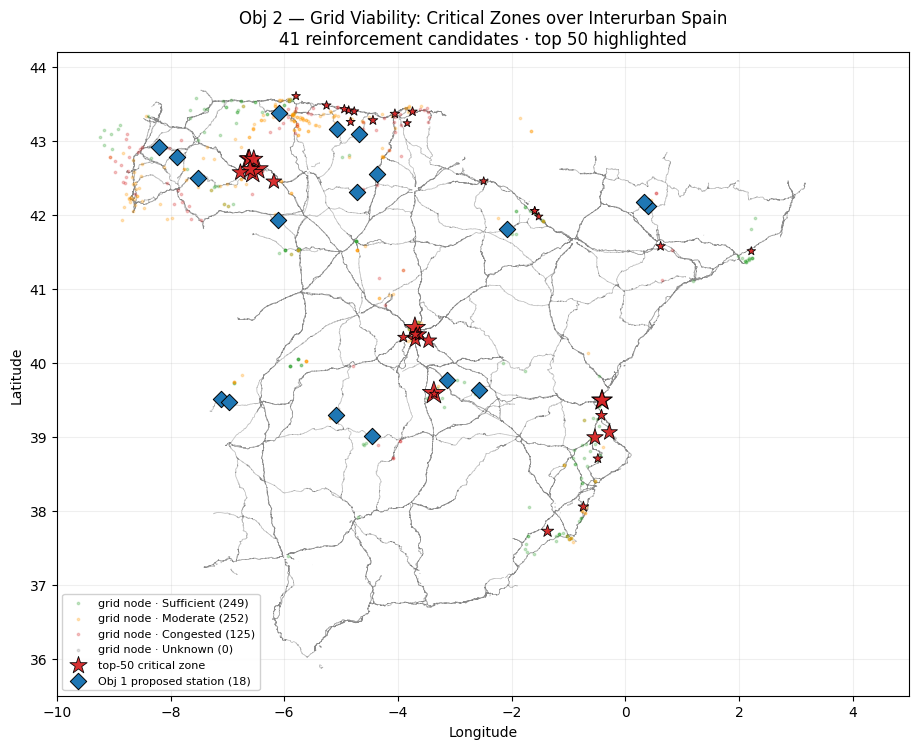

Saved map -> /sessions/relaxed-friendly-einstein/mnt/Iberdrola_Datathon/03_grid_viability/figures/critical_zones_map.png


In [10]:
fig, ax = plt.subplots(figsize=(11, 9))

# 1) interurban roads
roads.to_crs(4326).plot(ax=ax, color="#888888", linewidth=0.5, alpha=0.6, zorder=1)

# 2) all substations, faded, coloured by status
status_colour = {"Sufficient":"#2ca02c", "Moderate":"#ff9900", "Congested":"#d62728", "Unknown":"#888888"}
for st, c in status_colour.items():
    sub = grid[grid["grid_status"] == st]
    ax.scatter(sub["lon"], sub["lat"], s=3, c=c, alpha=0.25,
               label=f"grid node · {st} ({len(sub):,})", zorder=2)

# 3) top-50 critical zones highlighted
top50 = critical_out.head(50)
sizes = 40 + 260 * (top50["priority_score"] / top50["priority_score"].max())
ax.scatter(top50["longitude"], top50["latitude"], s=sizes, marker="*",
           edgecolor="black", facecolor="#d62728", linewidth=0.6, alpha=0.95,
           label=f"top-50 critical zone", zorder=4)

# 4) 18 proposed stations from File_2
ax.scatter(file2["longitude"], file2["latitude"], s=70, marker="D",
           edgecolor="black", facecolor="#1f77b4", linewidth=0.7,
           label=f"Obj 1 proposed station ({len(file2)})", zorder=5)

ax.set_xlim(-10, 5)
ax.set_ylim(35.5, 44.2)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Obj 2 — Grid Viability: Critical Zones over Interurban Spain\n"
             f"{len(critical_out):,} reinforcement candidates · top 50 highlighted",
             fontsize=12)
ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
ax.grid(alpha=0.2)

fig_path = FIGDIR / "critical_zones_map.png"
fig.savefig(fig_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved map -> {fig_path}")


## 11 · Alignment verification against Objective 1

* **File_3 untouched:** `File_3.csv` still has 14 rows and exactly the 7 mandatory columns — no schema drift.
* **Same classification bands:** `critical_zones.csv` uses the same `<1 / 1-5 / >5 MW` bands as `File_2.csv`, so a node appearing in both outputs has the same `grid_status`.
* **Feasibility gate respected:** zero-MW nodes are already excluded from the node universe before scoring, matching Obj 1's build rule.
* **Distributor vocabulary:** all values in `distributor_network` belong to `{i-DE, Endesa, Viesgo}` — Rule 1 compliant.
* **Additive, not contradictory:** every File_3 friction-point (14 rows) has a counterpart in the broader critical_zones map; critical_zones simply widens the analysis to the full grid.

In [11]:
# A) check File_3 is untouched
f3_now = pd.read_csv(OUT / 'File_3.csv')
assert len(f3_now) == 14, 'File_3 row count changed!'
assert list(f3_now.columns) == ['bottleneck_id','latitude','longitude','route_segment',
                                 'distributor_network','estimated_demand_kw','grid_status'], \
       'File_3 schema drift!'
print(f"OK  File_3 unchanged: {len(f3_now)} rows, {len(f3_now.columns)} cols")

# B) classification consistency: a File_2 row's grid_status should equal the band its
# coordinates fall into in the grid_nodes universe (nearest-node match)
from scipy.spatial import cKDTree
tree_g = cKDTree(grid[['lon','lat']].values)
f2_xy  = file2[['longitude','latitude']].values
d, i   = tree_g.query(f2_xy, k=1)
f2_check = file2.copy()
f2_check['nearest_status'] = grid.iloc[i]['grid_status'].values
f2_check['nearest_dist_km'] = d / DEG_PER_KM
mismatches = (f2_check['grid_status'] != f2_check['nearest_status']).sum()
print(f"OK  File_2 nearest-node band agreement: {len(f2_check)-mismatches}/{len(f2_check)} rows")

# C) distributor_network vocabulary is datathon-compliant
assert set(critical_out['distributor_network'].unique()) <= {'i-DE','Endesa','Viesgo'}, \
       'Non-compliant distributor_network values in critical_zones!'
print(f"OK  critical_zones distributor_network vocabulary: {sorted(critical_out['distributor_network'].unique())}")

# D) Sufficient must NOT appear
assert (critical_out['grid_status'] == 'Sufficient').sum() == 0, 'Sufficient in critical_zones!'
print(f"OK  Sufficient count in critical_zones: 0")


OK  File_3 unchanged: 14 rows, 7 cols
OK  File_2 nearest-node band agreement: 17/18 rows
OK  critical_zones distributor_network vocabulary: ['Endesa', 'Viesgo', 'i-DE']
OK  Sufficient count in critical_zones: 0


## 12 · Conclusion

* Objective 2 is delivered through two complementary artefacts:
    1. **`File_3.csv`** — the mandatory 14-row friction-point log, Moderate/Congested proposed stations only (unchanged from Obj 1).
    2. **`critical_zones.csv`** — the network-wide reinforcement roadmap, scoring every interurban-relevant substation by `deficit × demand`.
* **The map** makes the spatial logic self-evident: red stars cluster in the inland ~0-5 MW belt along the A-6 / N-VI, A-62, N-120, A-67, N-630 corridors — exactly where Iberdrola must pair grid capex with charger rollout.
* **Feeds into Deliverable 3** (BI Visualization) as an additional critical-zone layer, and into the Analytical Report's phased-rollout section (Objective 3).